## Suivi par MPOUAVOULI Rayde Prosperin
## Chapitre 2: Analyser les rendements et la volatité

### Objectif
#### - Calculer et interpreter les rendements(simples, cumulés)
#### - Mesurer et representer la volatilité d'un actif 
#### - Utiliser des visualisations pour suivre et comparer des performances financières

#### 1- Importer les données Apple

In [30]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [5]:
apple = yf.download("AAPL", start ="2020-01-01", end ="2024-12-31")
apple.columns =apple.columns.droplevel("Ticker")
apple.head()

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_17248\2377020740.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  apple = yf.download("AAPL", start ="2020-01-01", end ="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400
2020-01-03,71.833298,72.594063,71.608692,71.765674,146322800
2020-01-06,72.405670,72.444313,70.703005,70.954181,118387200
2020-01-07,72.065155,72.671348,71.845377,72.415345,108872000
2020-01-08,73.224396,73.526287,71.768071,71.768071,132079200


### 2- Calculer les rendements et performances

#### Le rendement mesure la variation relative du prix d'un actif entre deux périodes. C'est un indicateur clé de performance.

$R_t = \dfrac{P_t - P_{t-1}}{P_{t-1}} = \left(\dfrac{P_t}{P_{t-1}}\right) - 1$


In [12]:
apple["DailyReturn_manual"] = (apple["Close"] - apple["Close"].shift(1))/  apple["Close"].shift(1)
apple["DailyReturn_manual"].describe()

count    1256.000000
mean        0.001189
std         0.019962
min        -0.128647
25%        -0.008426
50%         0.001210
75%         0.012017
max         0.119808
Name: DailyReturn_manual, dtype: float64

In [15]:
apple["DailyReturn_mpct_change"] = apple["Close"].pct_change()
apple["DailyReturn_mpct_change"].describe()

count    1256.000000
mean        0.001189
std         0.019962
min        -0.128647
25%        -0.008426
50%         0.001210
75%         0.012017
max         0.119808
Name: DailyReturn_mpct_change, dtype: float64

In [17]:
apple["diff"] = apple["DailyReturn_mpct_change"]- apple["DailyReturn_manual"] 
apple["diff"].describe()

count    1256.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: diff, dtype: float64

### 3- Visualiser les rendements

In [ ]:
apple["DailyReturn_mpct_change"].describe()

Text(0.5, 0, 'Date')

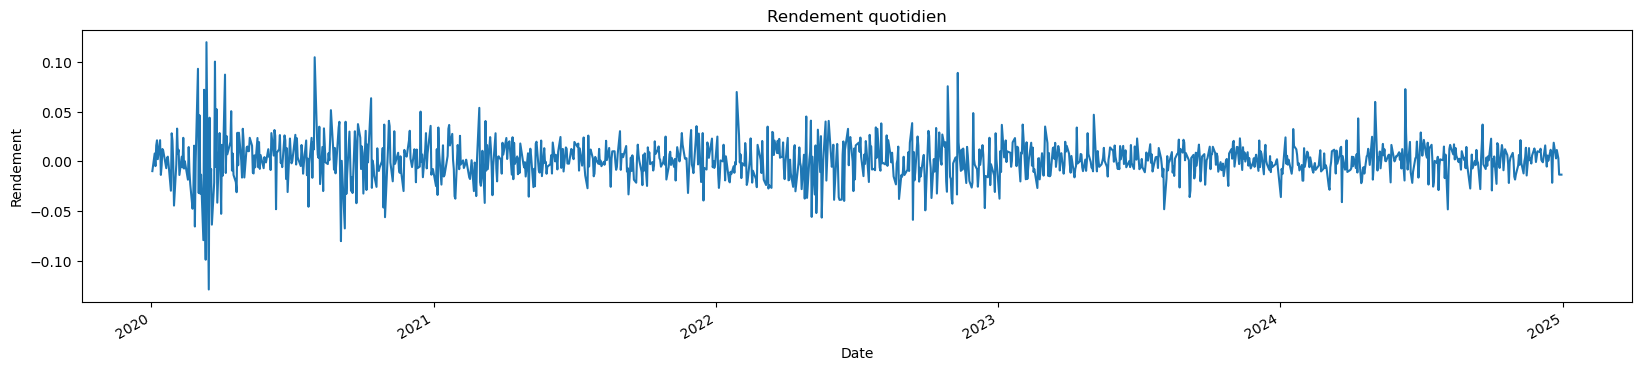

In [32]:
plt.figure(figsize = (20,4))
apple["DailyReturn_mpct_change"].plot(title ="Rendement quotidien")
plt.ylabel("Rendement")
plt.xlabel("Date")

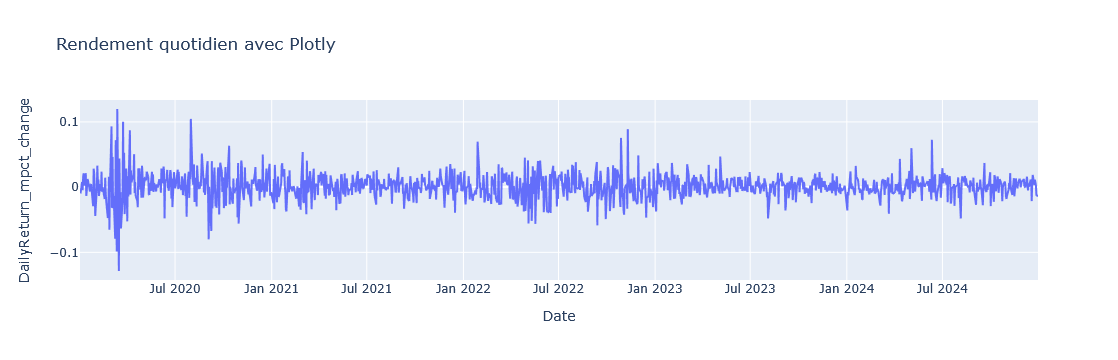

In [39]:
#Visualisation des rendements quotidiens calculés par pct_change avec ploty
import plotly.express as px
fig = px.line(
    apple,
    x=apple.index,
    y='DailyReturn_mpct_change',
    title="Rendement quotidien avec Plotly"
)

fig.show()


Text(0.5, 0, 'Date')

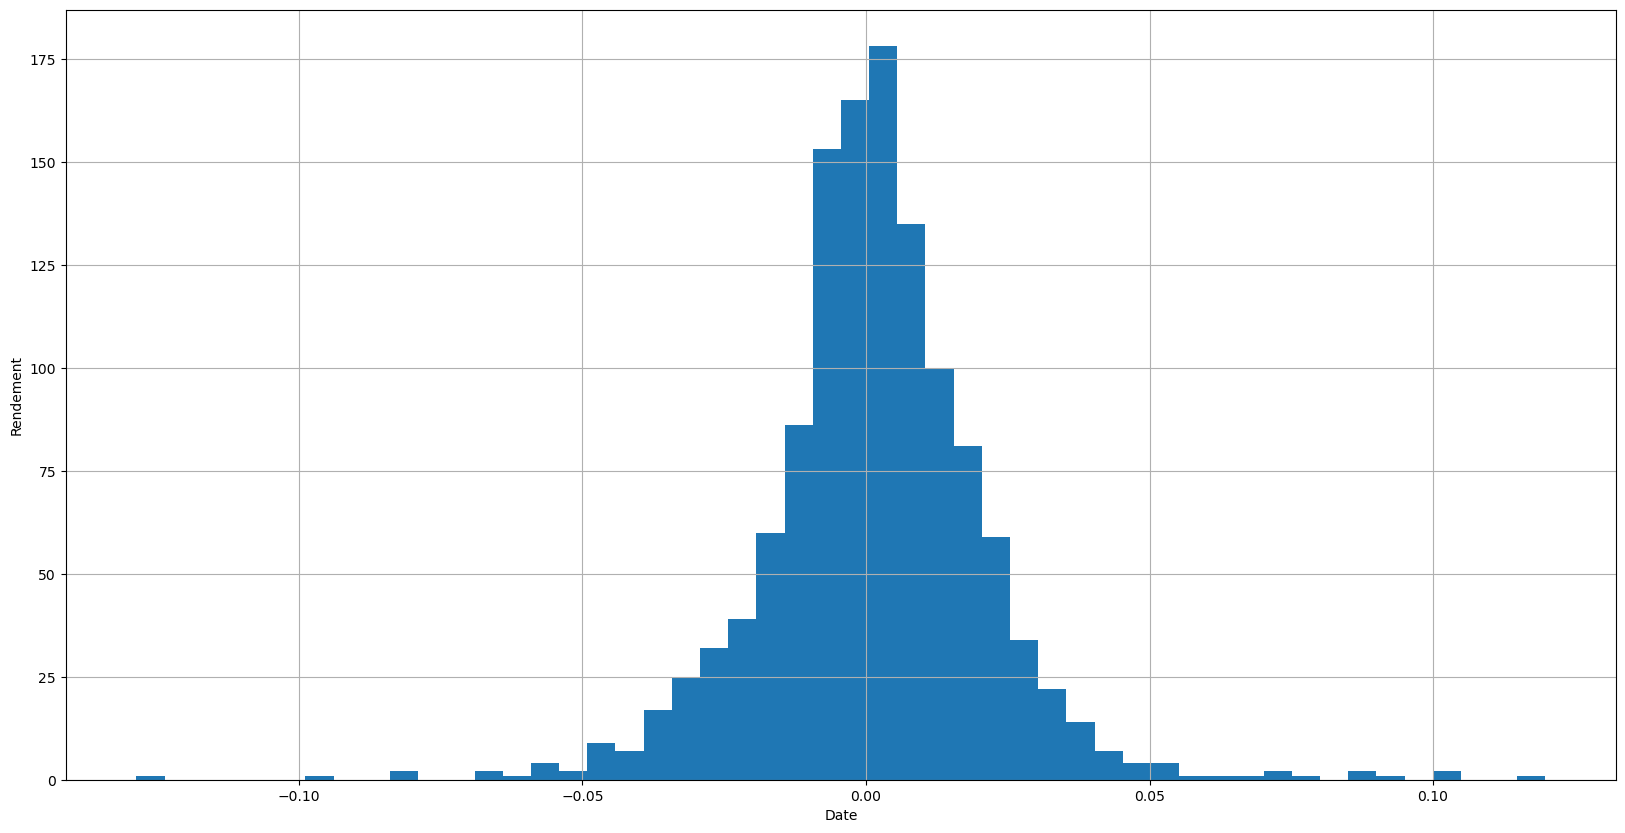

In [42]:
#Histogramme
plt.figure(figsize=(20,10))
apple['DailyReturn_mpct_change'].hist(bins=50)
plt.ylabel("Rendement")
plt.xlabel("Date")

### 4- Mesurer et analyser les rendements cumulés

#### Le rendement cumulé mesure la performance globale d'un actif dans le temps. Il permet d'observer l'effet composé des rendements successifs

$$
R_{t}^{cumulé} = \prod_{i=1}^{t} (1 + R_i) - 1
$$

In [48]:
apple['CumulativeReturn'] = (1 + apple['DailyReturn_mpct_change']).cumprod()
apple.head()

Price,Close,High,Low,Open,Volume,DailyReturn_manual,DailyReturn_mpct_change,diff,CumulativeReturn
Date,,,,,,,,,
2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400,NaN,NaN,NaN,NaN
2020-01-03,71.833298,72.594063,71.608692,71.765674,146322800,-0.009722,-0.009722,0.0,0.990278
2020-01-06,72.405670,72.444313,70.703005,70.954181,118387200,0.007968,0.007968,0.0,0.998169
2020-01-07,72.065155,72.671348,71.845377,72.415345,108872000,-0.004703,-0.004703,0.0,0.993474
2020-01-08,73.224396,73.526287,71.768071,71.768071,132079200,0.016086,0.016086,0.0,1.009455


Text(0.5, 0, 'Date')

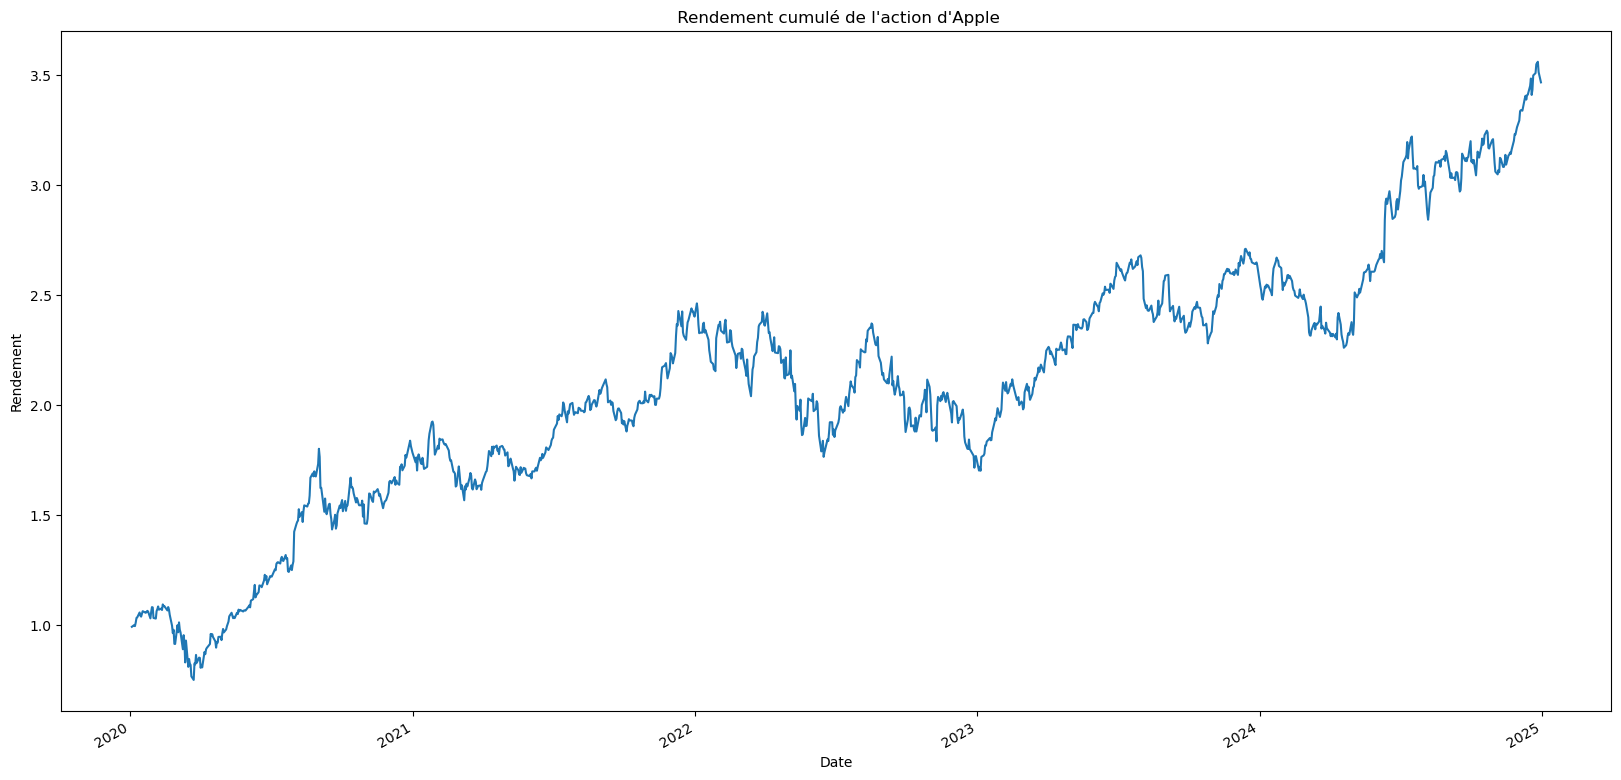

In [49]:
plt.figure(figsize=(20,10))
apple['CumulativeReturn'].plot(title=" Rendement cumulé de l'action d'Apple")
plt.ylabel("Rendement")
plt.xlabel("Date")

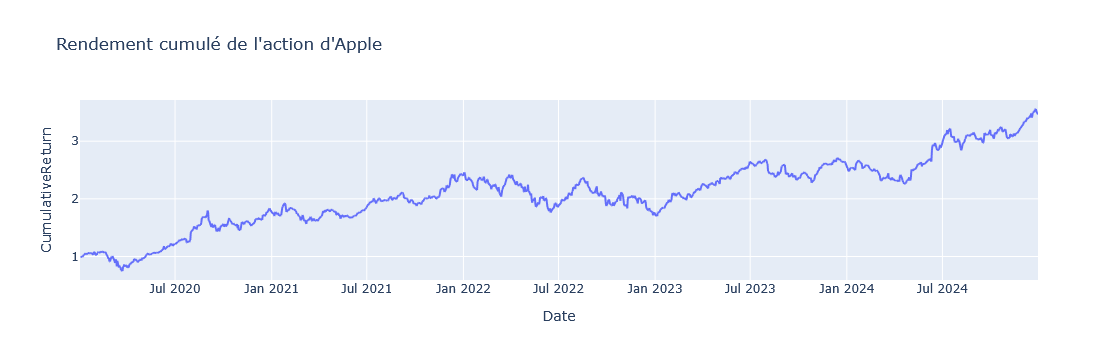

In [50]:
fig = px.line(
    apple,
    x=apple.index,
    y='CumulativeReturn',
    title="Rendement cumulé de l'action d'Apple"
)

fig.show()


Text(0.5, 0, 'Date')

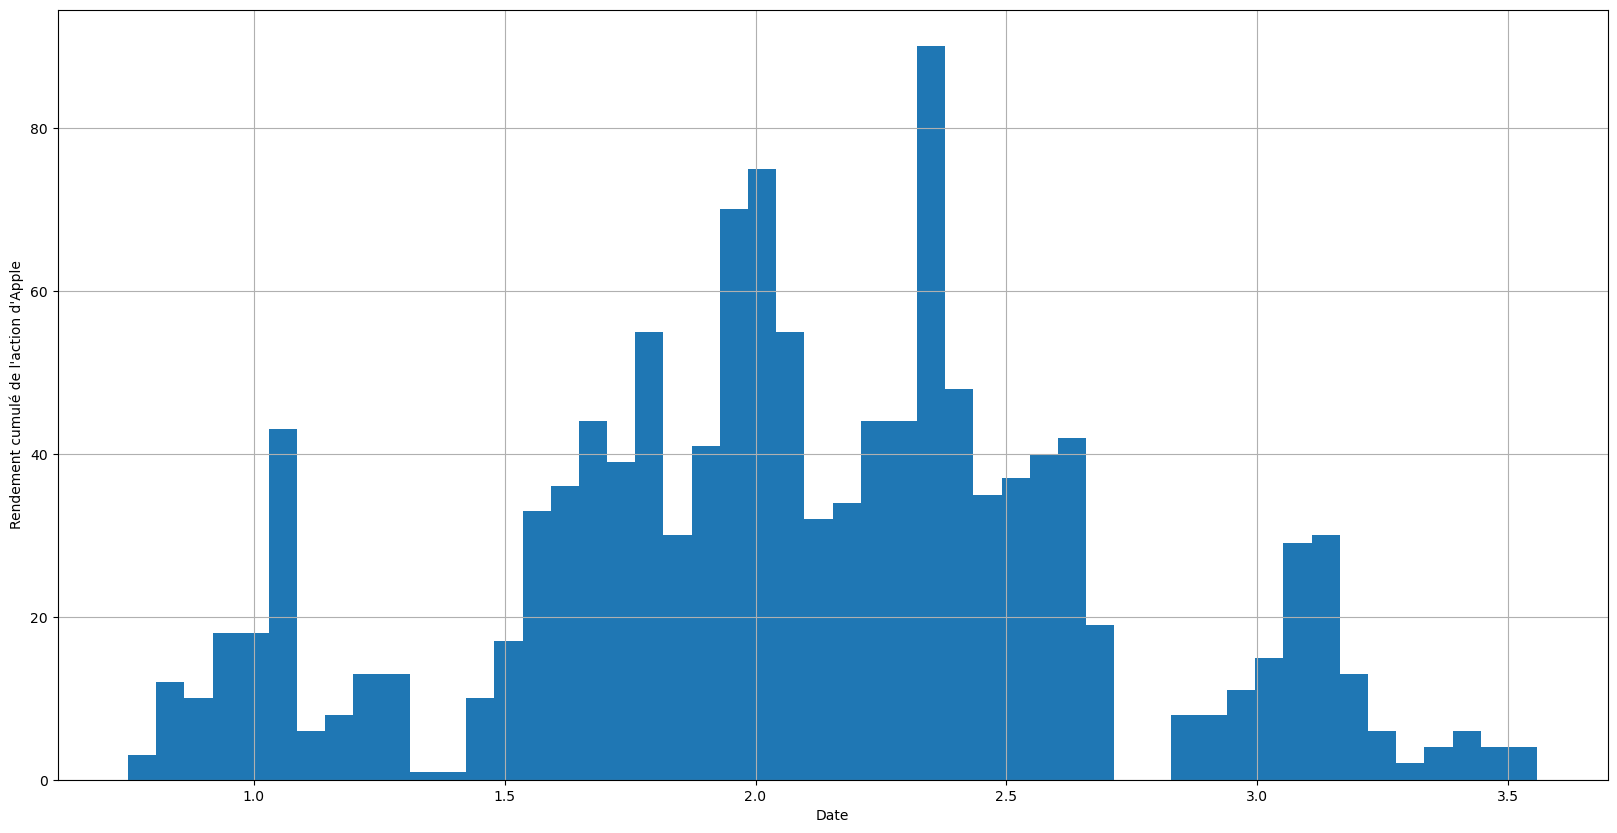

In [51]:
plt.figure(figsize=(20,10))
apple['CumulativeReturn'].hist(bins=50)
plt.ylabel("Rendement cumulé de l'action d'Apple")
plt.xlabel("Date")

### 5- Mesurer et interpreter la volatilité

#### La volatilité mesure l'ampleur des fluctuations du rendement d'un actif. C'est un indicateur clé du risque financier: plus elle est élévée, plus l'actif est instable.

$$
\sigma_R = \sqrt{\frac{1}{T - 1} \sum_{t=1}^{T} (R_t - \bar{R})^2}
$$


In [60]:
apple["Volatility_Daily"]= apple["DailyReturn_mpct_change"].rolling(window=21).std()
apple.head(22)

Price,Close,High,Low,Open,Volume,DailyReturn_manual,DailyReturn_mpct_change,diff,CumulativeReturn,Volatility_Daily
Date,,,,,,,,,,
2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400,NaN,NaN,NaN,NaN,NaN
2020-01-03,71.833298,72.594063,71.608692,71.765674,146322800,-0.009722,-0.009722,0.0,0.990278,NaN
2020-01-06,72.405670,72.444313,70.703005,70.954181,118387200,0.007968,0.007968,0.0,0.998169,NaN
2020-01-07,72.065155,72.671348,71.845377,72.415345,108872000,-0.004703,-0.004703,0.0,0.993474,NaN
2020-01-08,73.224396,73.526287,71.768071,71.768071,132079200,0.016086,0.016086,0.0,1.009455,NaN
2020-01-09,74.779762,74.972970,73.951373,74.202542,170108400,0.021241,0.021241,0.0,1.030897,NaN
2020-01-10,74.948807,75.513954,74.446462,75.014020,140644800,0.002261,0.002261,0.0,1.033228,NaN
2020-01-13,76.550041,76.576611,75.146850,75.265196,121532000,0.021364,0.021364,0.0,1.055302,NaN
2020-01-14,75.516373,76.697376,75.393206,76.487261,161954400,-0.013503,-0.013503,0.0,1.041052,NaN


$$
\sigma_{annuelle} = \sigma_{périodique} \times \sqrt{N}
$$


In [62]:
#Annualiser
apple["Volatility_Annualized"]= apple["Volatility_Daily"]*(252**0.5)
apple.tail()

Price,Close,High,Low,Open,Volume,DailyReturn_manual,DailyReturn_mpct_change,diff,CumulativeReturn,Volatility_Daily,Volatility_Annualized
Date,,,,,,,,,,,
2024-12-23,254.367035,254.745680,252.553466,253.868804,40858800,0.003065,0.003065,0.0,3.506648,0.008669,0.137616
2024-12-24,257.286682,257.296626,254.386957,254.586262,23234700,0.011478,0.011478,0.0,3.546898,0.008772,0.139258
2024-12-26,258.103729,259.179926,256.718662,257.276679,27237100,0.003176,0.003176,0.0,3.558161,0.008616,0.136768
2024-12-27,254.685883,257.784897,252.164833,256.917949,42355300,-0.013242,-0.013242,0.0,3.511044,0.009431,0.149709
2024-12-30,251.307861,252.603266,249.862994,251.337754,35557500,-0.013263,-0.013263,0.0,3.464475,0.010123,0.160691


In [63]:
apple["Volatility_Daily"].mean()*100

np.float64(1.8133436842551465)

In [64]:
apple["Volatility_Annualized"].mean()*100

np.float64(28.785938580172495)

### Visualisation de la volatilité

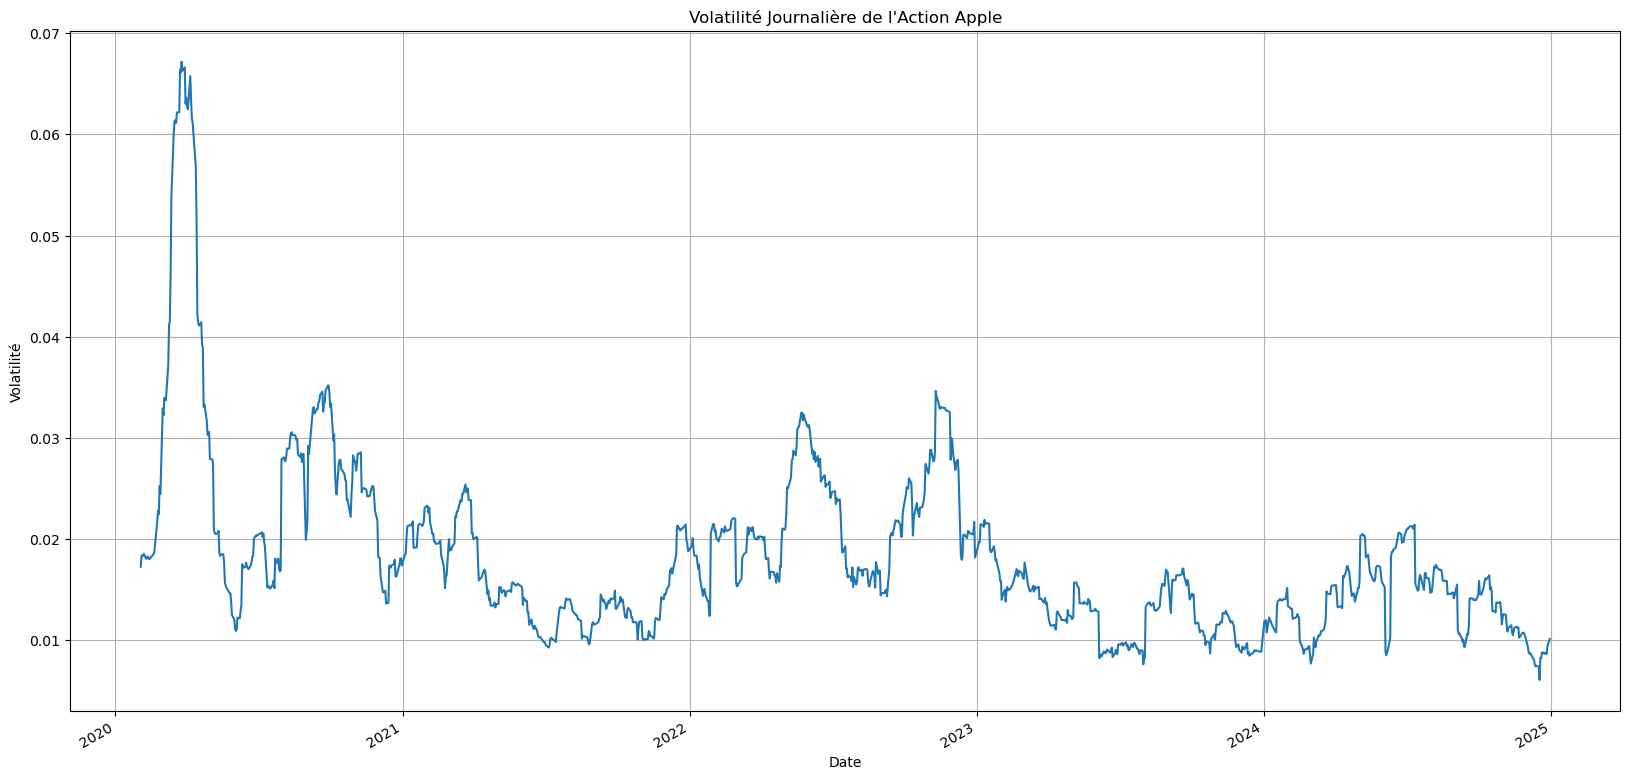

In [68]:
plt.figure(figsize=(20,10))
apple['Volatility_Daily'].plot(title="Volatilité Journalière de l'Action Apple")
plt.xlabel('Date')
plt.ylabel('Volatilité')
plt.grid(True)
plt.show()

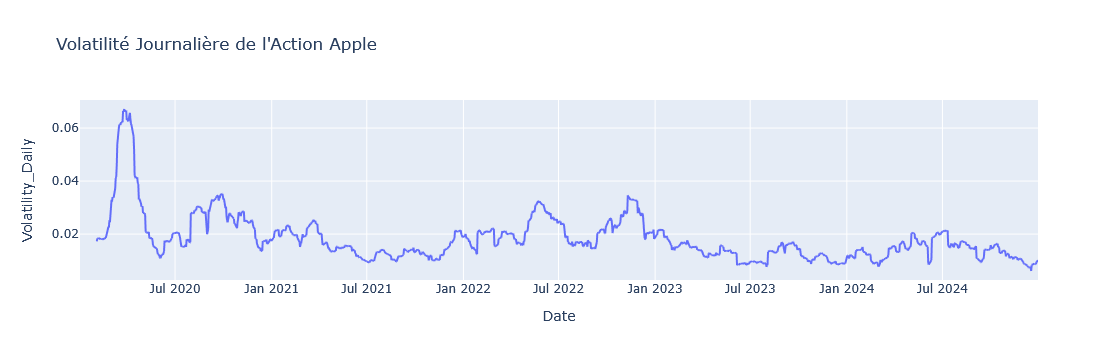

In [72]:
fig = px.line(apple, x=apple.index, y='Volatility_Daily', title="Volatilité Journalière de l'Action Apple")
fig.show()

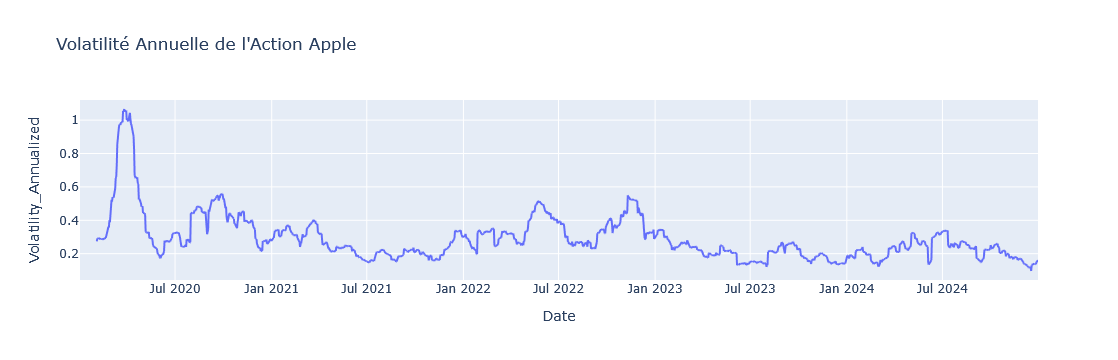

In [71]:
fig = px.line(apple, x=apple.index, y='Volatility_Annualized',title="Volatilité Annuelle de l'Action Apple")
fig.show()